In [1]:
rm(list = ls())
gc(reset = T)


library(xgboost)
library(dplyr)
library(dplyr)
library(evola.exp)
library(TSA)
library(forecast)
library(lubridate)
library(tidyr)
library(ggplot2)

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,653051,34.9,1446685,77.3,653051,34.9
Vcells,1199357,9.2,8388608,64.0,1199357,9.2



Adjuntando el paquete: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union



Adjuntando el paquete: 'TSA'


The following objects are masked from 'package:stats':

    acf, arima


The following object is masked from 'package:utils':

    tar


Registered S3 methods overwritten by 'forecast':
  method       from
  fitted.Arima TSA 
  plot.Arima   TSA 


Adjuntando el paquete: 'lubridate'


The following objects are masked from 'package:base':

    date, intersect, setdiff, union




In [4]:
#Cargar datos

evola.exp::def_user(user = "evazquez", servidor = "165")



#modelando desde 2010 corrige errores de meses problematicos
## Year selection
year1 <- 2010
#  con 1989 me salen 13 dias en promedio

# con año 2000 el promedio aumento a 14 dias

# con año 2010 el promeidio subio 1 21 dias


year2 <- as.numeric(format(Sys.Date(), "%Y")) -1
years <- c(2001, 2008, 2012, 2018, 2021)

# =========================
# 1) Meteorologia HORARIA
# =========================

temperatura <- evola.exp::redes_con(
  red = "redmet",
  parametros = "tmp",
  start = year1,
  end = year2
)




v_viento <- evola.exp::redes_con(
  red = "redmet",
  parametros = "wsp",
  start = year1,
  end = year2
)



In [5]:
head(v_viento)

,date,id_station,id_parameter,valor,unit
,<dttm>,<chr>,<chr>,<dbl>,<dbl>
1,2010-01-01,TAC,WSP,NA,3
2,2010-01-01,FAC,WSP,1.0,3
3,2010-01-01,SAG,WSP,1.5,3
4,2010-01-01,TLA,WSP,1.4,3
5,2010-01-01,XAL,WSP,0.6,3
6,2010-01-01,MER,WSP,1.7,3


In [6]:
# Promedios clima

# Promedio diario de temperatura
tmp.d <- temperatura %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    tmp = mean(valor, na.rm = TRUE),
    .groups = "drop"
  )


wsp.d <- v_viento %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    wsp = mean(valor, na.rm = TRUE),
    .groups = "drop"
  )

In [7]:
# =========================
# 2) O3 HORARIO
# =========================
o3.h <- evola.exp::redes_con(start = year1, end = year2)

o3.ht <- evola.exp::redes_con(
  start = year1,
  end = year2,
  temporal = TRUE
) %>%
  dplyr::filter(!date %in% o3.h$date)

o3.h <- rbind(o3.h, o3.ht) %>%
  dplyr::filter(
    !(as.numeric(format(date, "%Y")) >= 2017 &
        id_station %in% c("ACO", "AJU", "INN", "MON", "MPA"))
  )

In [8]:
# =========================
# 3) MAXIMOS DIARIOS O3
# =========================
o3.d <- o3.h %>%
  mutate(date = as.Date(date)) %>%
  group_by(date) %>%
  summarise(
    valor = if (all(is.na(valor))) {
      NA_real_
    } else {
      max(valor, na.rm = TRUE)
    },
    .groups = "drop"
  )

In [12]:
# =========================
# 4) UNIR O3 DIARIO + TMP DIARIA
# =========================
base.d <- o3.d %>%
  left_join(tmp.d, by = "date") %>%
  left_join(wsp.d, by = "date") 

base.dd <- base.d %>% select(-c(date))


In [14]:
# Matriz de Correlación
cor(base.dd)

cor(base.dd, use = "complete.obs")

,valor,tmp,wsp
valor,1.0000000,0.4791035,-0.3035105
tmp,0.4791035,1.0000000,0.1872948
wsp,-0.3035105,0.1872948,1.0000000


,valor,tmp,wsp
valor,1.0000000,0.4791035,-0.3035105
tmp,0.4791035,1.0000000,0.1872948
wsp,-0.3035105,0.1872948,1.0000000


In [15]:
# =========================
# 5) AGREGAR A NIVEL MENSUAL
#    MISMA TEMPORALIDAD PARA y y xreg
# =========================

o3.temp <- base.d %>%
  dplyr::filter(
    format(date, "%m") %in% sprintf("%02d", 2:6),
    !format(date, "%m-%d") %in% paste("02", sprintf("%02d", 1:14), sep = "-"),
    !format(date, "%m-%d") %in% paste("06", 16:30, sep = "-")
  ) %>%
  dplyr::group_by(
    year = as.numeric(format(date, "%Y")),
    month = as.numeric(format(date, "%m"))
  ) %>%
  dplyr::summarise(
    ndias = sum(valor >= 155),
    wsp_prom = mean(wsp, na.rm = TRUE),
    tmp_prom = mean(tmp, na.rm = TRUE),
    .groups = "drop"
  ) 

In [16]:
# Revisión rápida
print(head(o3.temp))
print(colSums(is.na(o3.temp)))

# A tibble: 6 × 5
   year month ndias wsp_prom tmp_prom
  <dbl> <dbl> <int>    <dbl>    <dbl>
1  2010     2     0     1.65     14.4
2  2010     3     3     1.75     18.1
3  2010     4     4     1.69     18.3
4  2010     5     5     1.72     20.2
5  2010     6     5     1.64     19.9
6  2011     2     0     1.74     16.7
    year    month    ndias wsp_prom tmp_prom 
       0        0        0        0        0 


In [18]:
# =========================
# 6) SERIE OBJETIVO Y MATRIZ xreg
# =========================
o3.ts <- ts(
  o3.temp$ndias,
  start = c(min(o3.temp$year), min(o3.temp$month)),
  frequency = 5
)

# Preparar base
o3.xgb <- o3.temp 

# Train / test temporal
train <- o3.xgb %>%
  filter(year <= 2018)

test <- o3.xgb %>%
  filter(year >= 2019)

# Variables predictoras
x_train <- as.matrix(train[, c("year", "month", "tmp_prom", "wsp_prom")])
y_train <- train$ndias

x_test <- as.matrix(test[, c("year", "month", "tmp_prom", "wsp_prom")])
y_test <- test$ndias

# Convertir a formato XGBoost
dtrain <- xgb.DMatrix(data = x_train, label = y_train)
dtest  <- xgb.DMatrix(data = x_test, label = y_test)

# Modelo
modelo_xgb <- xgboost(
  x = x_train,
  y = y_train,
  objective = "reg:squarederror",
  nrounds = 300, # ya probe 100
  learning_rate = 0.03, # 0.05
  max_depth = 1, # ya probe 2 
  subsample = 0.8,
  colsample_bytree = 0.8
)

# Predicción
pred_xgb <- predict(modelo_xgb, x_test)

In [19]:
# Métricas
error <- y_test - pred_xgb

MAE <- mean(abs(error), na.rm = TRUE)
RMSE <- sqrt(mean(error^2, na.rm = TRUE))
ME <- mean(error, na.rm = TRUE)

data.frame(
  ME = ME,
  RMSE = RMSE,
  MAE = MAE
)


ME,RMSE,MAE
<dbl>,<dbl>,<dbl>
-0.8405422,2.222401,1.669011


    Feature      Gain     Cover Frequency
     <char>     <num>     <num>     <num>
1: tmp_prom 0.6058553 0.3932225 0.3933333
2:    month 0.1407208 0.1764706 0.1733333
3: wsp_prom 0.1361772 0.2211363 0.2233333
4:     year 0.1172467 0.2091706 0.2100000


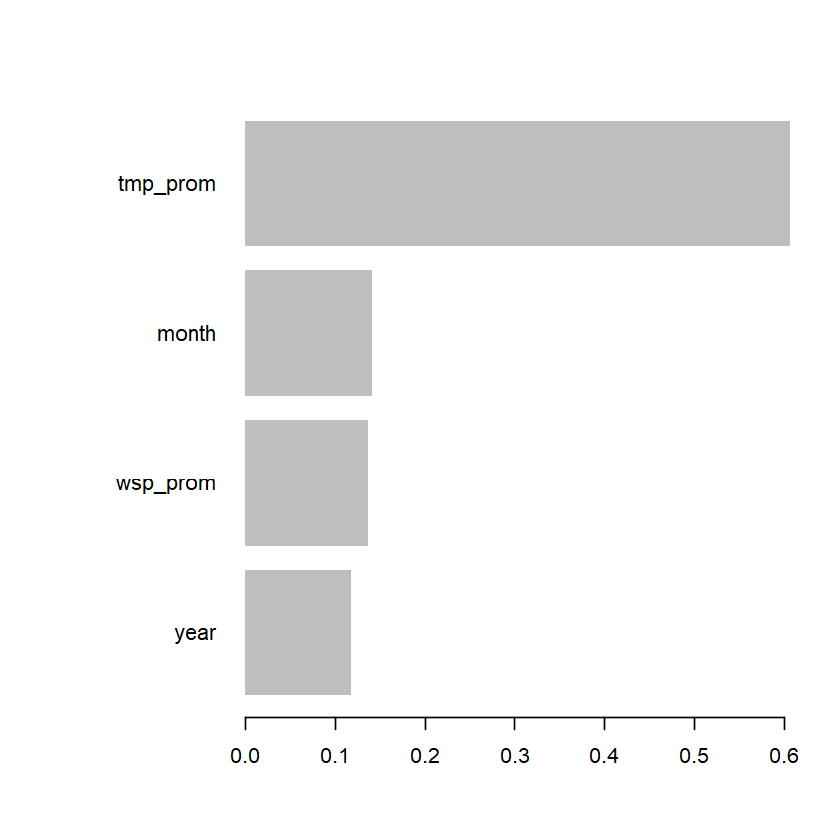

In [20]:
# Importancia de variables

importance <- xgb.importance(
  feature_names = colnames(x_train),
  model = modelo_xgb
)

print(importance)

xgb.plot.importance(importance)

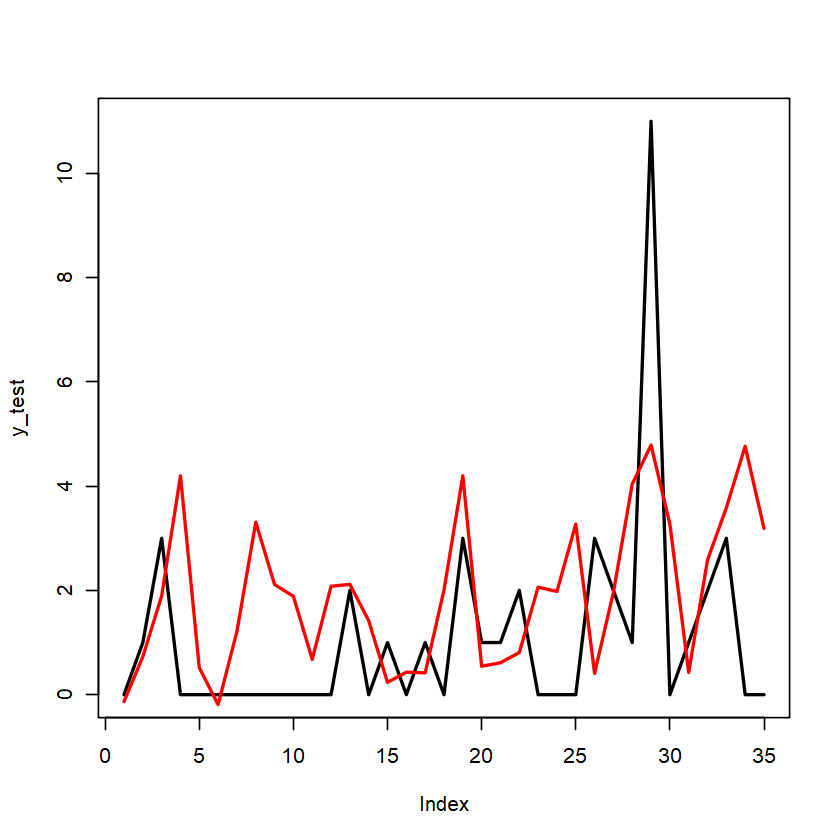

In [21]:
# Grafica real vs predicho

plot(y_test, type = "l", lwd = 2)
lines(pred_xgb, col = "red", lwd = 2)

In [22]:
# Ver donde falla

data.frame(
  year = test$year,
  month = test$month,
  real = y_test,
  pred = round(pred_xgb, 1),
  error = round(y_test - pred_xgb, 1)
)

year,month,real,pred,error
<dbl>,<dbl>,<int>,<dbl>,<dbl>
2019,2,0,-0.1,0.1
2019,3,1,0.7,0.3
2019,4,3,1.9,1.1
2019,5,0,4.2,-4.2
2019,6,0,0.5,-0.5
2020,2,0,-0.2,0.2
2020,3,0,1.2,-1.2
2020,4,0,3.3,-3.3
2020,5,0,2.1,-2.1


In [25]:
# ---- Pronostico ----

# meteorolgia futura

clima_tmp <- o3.temp %>%
  group_by(month) %>%
  summarise(
    tmp_prom = mean(tmp_prom, na.rm = TRUE)
  )


clima_wsp <- o3.temp %>%
  group_by(month) %>%
  summarise(
    wsp_prom = mean(wsp_prom, na.rm = TRUE)
  )

# Base futura

future_data <- data.frame(
  year = 2026,
  month = 2:6
)


# Unir bases
future_data <- future_data %>%
  left_join(clima_tmp, by = "month") %>%
  left_join(clima_wsp, by = "month")


# Crear matriz

x_future <- as.matrix(
  future_data[, c("year", "month", "tmp_prom", "wsp_prom")]
)


# Pronostico
pred_future <- predict(modelo_xgb, x_future)


# Ver resultados

future_data$pred_ndias <- round(pred_future)

# tabla con margen de error minimo con MAE
# maximo con RMSE para valores extremos

mae_modelo <- round(MAE,2)

rmse_modelo <- round(RMSE,2)

future_data <- future_data %>%
  mutate(
    Minimo = pmax(round(pred_ndias - mae_modelo), 0),
    Promedio = round(pred_ndias),
    Maximo = round(pred_ndias + rmse_modelo)
  )

future_data <- future_data %>%
  mutate(month = as.character(month))


total_2026 <- future_data %>%
  summarise(
    year = 2026,
    month = "Total",
    tmp_prom = NA,
    wsp_prom = NA,
    pred_ndias = sum(pred_ndias, na.rm = TRUE),
    Minimo = sum(Minimo, na.rm = TRUE),
    Promedio = sum(Promedio, na.rm = TRUE),
    Maximo = sum(Maximo, na.rm = TRUE)
  )

future_data_total <- bind_rows(
  future_data,
  total_2026
)

future_data_total

year,month,tmp_prom,wsp_prom,pred_ndias,Minimo,Promedio,Maximo
<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2026,2,16.48688,2.033828,0,0,0,2
2026,3,17.46302,2.179242,1,0,1,3
2026,4,18.88544,2.209801,2,0,2,4
2026,5,19.44233,2.143316,5,3,5,7
2026,6,18.84143,2.198447,1,0,1,3
2026,Total,NA,NA,9,3,9,19
